In [2]:
import sys
sys.path.append('../')
import os
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from src.IO import ExperimentLoader
from src.environment import LigandEnvironment, LogNormalConcentration
from src.physics import BinaryReceptor
from objectives.loss import ExactInformationLoss
from src import plot_latent_umap

PARAMETER SWEEP
The script runs a massive parallelized sweep across varying levels of environmental complexity and genetic restrictions:
- `n_families` (Environmental Complexity): [1, 2, 3, 5, 10, 20]
- `latent_dim` (Chemical Space Dimension): [3, 7, 10]
- `n_units` (Number of Available Genes): [1, 2, 3, 5, 7, 8, 10, 12, 15, 20, 30, 50]
- `n_samples` (Trials): 5 independent simulation runs per configuration to measure statistical variance and stability.

OUTPUTS
Data is recursively saved to: `/app/data/families_<n_families>/dim_<latent_dim>/n_units_<n_units>/sample_<sample_id>/`
Each run folder generates:
- `config.json`: The specific parameters for the trial.
- `stats.csv`: Epoch-by-epoch training metrics, including the array's differential entropy and mean receptor distances.
- `best_model.pt`: The optimized neural network/environment weights.
- `test_results.json`: Independent post-training evaluation measurements of the array's entropy, used to calculate confidence intervals and standard deviations.

By increasing both the number of families and the latent dimension, the simulation assesses how effectively combinatorial receptor arrays (homomeric vs. heteromeric) can break the "discretization bottleneck" and utilize their full theoretical coding capacity in highly complex environments.

In [3]:
# Load all experiments across the parameter sweep
base_paths = {
    'homomers': Path("../data/homomers/"),
    #'heteromers': Path("../data/heteromers/")
}
experiments = {}

for exp_type, base_data_path in base_paths.items():
    if not base_data_path.exists():
        continue
    for f_dir in base_data_path.glob("families_*"):
        n_families = int(f_dir.name.split("_")[1])
        for d_dir in f_dir.glob("dim_*"):
            latent_dim = int(d_dir.name.split("_")[1])
            for u_dir in d_dir.glob("n_units_*"):
                n_units = int(u_dir.name.split("_")[2])
                receptor_dirs = list(u_dir.glob("n_receptors_*")) if exp_type == 'heteromers' else [u_dir]
                
                for r_dir in receptor_dirs:
                    n_receptors = int(r_dir.name.split("_")[2]) if exp_type == 'heteromers' else n_units
                    config_key = (exp_type, n_families, latent_dim, n_units, n_receptors)
                    
                    if config_key not in experiments:
                        experiments[config_key] = {'samples': [], 'test_entropies': []}
                    
                    for sample_dir in r_dir.glob("sample_*"):
                        try:
                            loader = ExperimentLoader(base_path=str(r_dir), experiment_name=sample_dir.name)
                            env, physics, loss_fn, receptor_indices, stats_df, config = loader.load_objects(filename="best_model.pt")
                            # Load test results for standard deviation estimation
                            test_json_path = sample_dir / "test_results.json"
                            test_entropies = []
                            if test_json_path.exists():
                                with open(test_json_path, "r") as f:
                                    test_entropies = json.load(f).get("full_array_entropy", [])
                            experiments[config_key]['samples'].append({
                                'env': env, 'physics': physics, 'receptor_indices': receptor_indices,
                                'stats_df': stats_df, 'test_entropies': test_entropies, 'config': config
                            })
                            experiments[config_key]['test_entropies'].extend(test_entropies)
                        except Exception as e:
                            print(e)
                            pass

print(f"Loaded {len(experiments)} unique configurations.")

Auto-discovered latest run: sample_0_20260414_101657
Auto-discovered latest run: sample_4_20260414_104143
Auto-discovered latest run: sample_1_20260414_102225
Auto-discovered latest run: sample_2_20260414_102846
Auto-discovered latest run: sample_3_20260414_103514
Auto-discovered latest run: sample_1_20260414_102019
Auto-discovered latest run: sample_0_20260414_101610
Auto-discovered latest run: sample_3_20260414_103246
Auto-discovered latest run: sample_4_20260414_103924
Auto-discovered latest run: sample_2_20260414_102609
Auto-discovered latest run: sample_1_20260414_102038
Auto-discovered latest run: sample_4_20260414_103945
Auto-discovered latest run: sample_2_20260414_102633
Auto-discovered latest run: sample_3_20260414_103309
Auto-discovered latest run: sample_0_20260414_101615
Auto-discovered latest run: sample_3_20260414_103333
Auto-discovered latest run: sample_2_20260414_102700
Auto-discovered latest run: sample_1_20260414_102059
Auto-discovered latest run: sample_0_20260414_

In [4]:
# Example: viewing stats for Homomers, Families=5, Dim=10, Units=10 (Sample 0)
example_key = ('homomers', 5, 10, 10, 10)
if example_key in experiments and len(experiments[example_key]['samples']) > 0:
    display(experiments[example_key]['samples'][0]['test_entropies'])
else:
    print('not in the folder')

[5.2842631340026855,
 5.265833377838135,
 5.278297424316406,
 5.286009311676025,
 5.277528285980225,
 5.275589942932129,
 5.295933246612549,
 5.301911354064941,
 5.275460243225098,
 5.287487983703613]

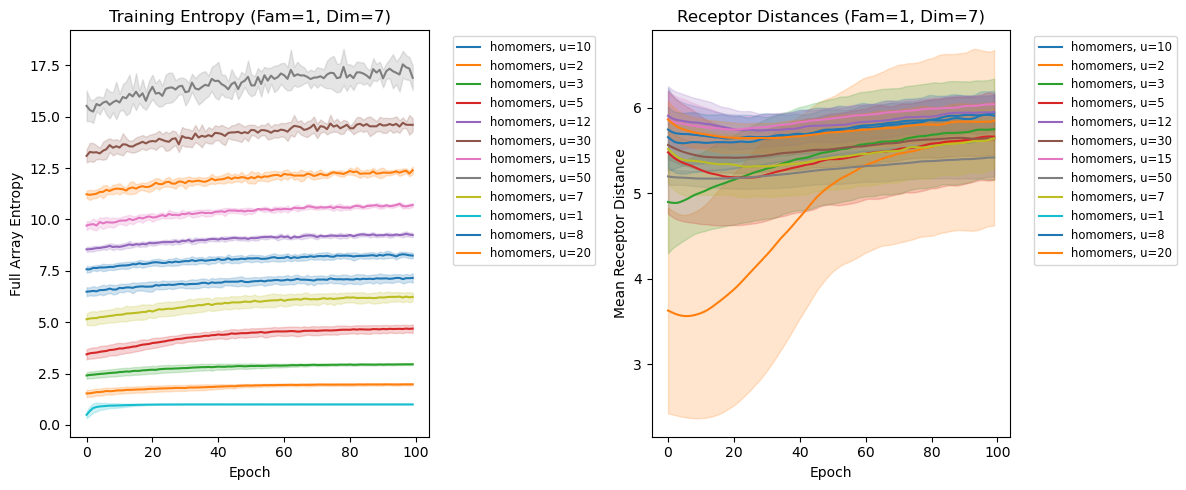

In [28]:
# Plot the training metrics (Mean & Std Dev) for a specific configuration
target_families = 1
target_dim = 7

fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

for config_key, exp_data in experiments.items():
    exp_type, n_families, latent_dim, n_units, n_receptors = config_key
    if n_families != target_families or latent_dim != target_dim or not exp_data['samples']:
        continue
    
    all_entropies = [s['stats_df']['full_array_entropy'].values for s in exp_data['samples']]
    all_distances = [s['stats_df']['mean_receptor_distance'].values for s in exp_data['samples']]
    epochs = exp_data['samples'][0]['stats_df']['epoch'].values
    
    # Standardize length if samples got interrupted
    min_len = min(len(e) for e in all_entropies)
    all_entropies = [e[:min_len] for e in all_entropies]
    all_distances = [d[:min_len] for d in all_distances]
    epochs = epochs[:min_len]
    
    mean_ent = np.mean(all_entropies, axis=0)
    std_ent = np.std(all_entropies, axis=0)
    mean_dist = np.mean(all_distances, axis=0)
    std_dist = np.std(all_distances, axis=0)
    
    label = f'{exp_type}, u={n_units}' + (f', r={n_receptors}' if exp_type == 'heteromers' else '')
    p = ax[0].plot(epochs, mean_ent, label=label)
    ax[0].fill_between(epochs, mean_ent - std_ent, mean_ent + std_ent, color=p[0].get_color(), alpha=0.2)
    
    p = ax[1].plot(epochs, mean_dist, label=label)
    ax[1].fill_between(epochs, mean_dist - std_dist, mean_dist + std_dist, color=p[0].get_color(), alpha=0.2)

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Full Array Entropy')
ax[0].set_title(f'Training Entropy (Fam={target_families}, Dim={target_dim})')
ax[0].legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')

ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Receptor Distance')
ax[1].set_title(f'Receptor Distances (Fam={target_families}, Dim={target_dim})')
ax[1].legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

[5]
[5]
[5]


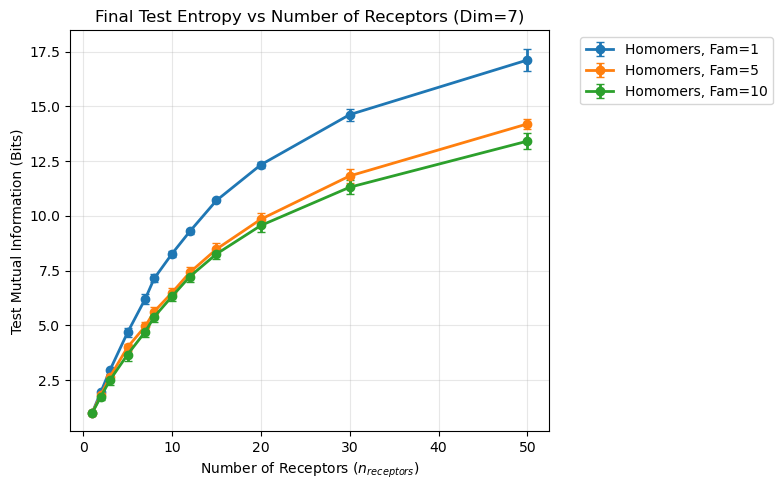


Fitting UMAP for Homomers, Fam=1, Dim=7, Units=10 (Sample 0)...
Fitting UMAP... (This may take a few seconds)


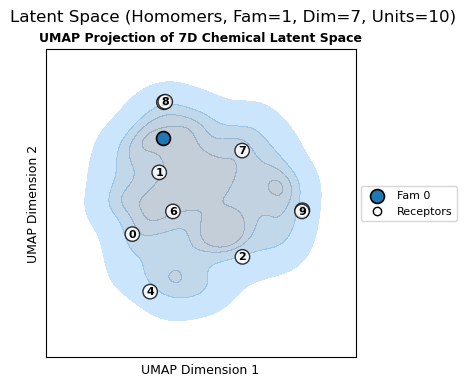


Fitting UMAP for Homomers, Fam=1, Dim=7, Units=20 (Sample 0)...
Fitting UMAP... (This may take a few seconds)


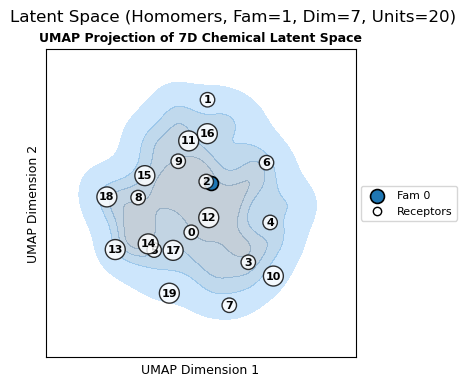

In [29]:
# Plot final Test Entropy (Mean +/- Std) vs n_receptors for different Families
fig, ax = plt.subplots(figsize=(8, 5))
families_to_plot = [1,5,10]

for fam in families_to_plot:
    # Plot Homomers
    x_rec_homo, y_means_homo, y_stds_homo = [], [], []
    for config_key, exp_data in experiments.items():
        exp_type, n_families, latent_dim, n_units, n_receptors = config_key
        if exp_type == 'homomers' and n_families == fam and latent_dim == target_dim and len(exp_data['test_entropies']) > 0:
            x_rec_homo.append(n_receptors)
            y_means_homo.append(np.mean(exp_data['test_entropies']))
            y_stds_homo.append(np.std(exp_data['test_entropies']))
    
    if x_rec_homo:
        sorted_indices = np.argsort(x_rec_homo)
        x_rec_homo = np.array(x_rec_homo)[sorted_indices]
        y_means_homo = np.array(y_means_homo)[sorted_indices]
        y_stds_homo = np.array(y_stds_homo)[sorted_indices]
        ax.errorbar(x_rec_homo, y_means_homo, yerr=y_stds_homo, marker='o', capsize=3, label=f'Homomers, Fam={fam}', linestyle='-', linewidth=2)

    # Plot Heteromers (Grouped by n_units)
    het_units = sorted(list(set(k[3] for k in experiments.keys() if k[0] == 'heteromers' and k[1] == fam and k[2] == target_dim)))
    het_units = [5]
    print(het_units)
    for u in het_units:
        x_rec_het, y_means_het, y_stds_het = [], [], []
        for config_key, exp_data in experiments.items():
            exp_type, n_families, latent_dim, n_units, n_receptors = config_key
            if exp_type == 'heteromers' and n_families == fam and latent_dim == target_dim and n_units == u and len(exp_data['test_entropies']) > 0:
                x_rec_het.append(n_receptors)
                y_means_het.append(np.mean(exp_data['test_entropies']))
                y_stds_het.append(np.std(exp_data['test_entropies']))
                
        if x_rec_het:
            sorted_indices = np.argsort(x_rec_het)
            x_rec_het = np.array(x_rec_het)[sorted_indices]
            y_means_het = np.array(y_means_het)[sorted_indices]
            y_stds_het = np.array(y_stds_het)[sorted_indices]
            ax.errorbar(x_rec_het, y_means_het, yerr=y_stds_het, marker='x', capsize=3, label=f'Heteromers (u={u}), Fam={fam}', linestyle='--', alpha=0.8)

ax.set_xlabel('Number of Receptors ($n_{receptors}$)')
ax.set_ylabel('Test Mutual Information (Bits)')
ax.set_title(f'Final Test Entropy vs Number of Receptors (Dim={target_dim})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot the latent space visualization for a specific best sample
units_to_plot = [10, 20]
for units in units_to_plot:
    config_key = ('homomers', target_families, target_dim, units, units)
    if config_key in experiments and len(experiments[config_key]['samples']) > 0:
        exp_data = experiments[config_key]['samples'][0]
        print(f"\nFitting UMAP for Homomers, Fam={target_families}, Dim={target_dim}, Units={units} (Sample 0)...")
        fig, ax = plot_latent_umap(exp_data['env'], exp_data['receptor_indices'])
        fig.suptitle(f"Latent Space (Homomers, Fam={target_families}, Dim={target_dim}, Units={units})")
        plt.show()

In [29]:
units_to_plot = [10, 20]
for exp_type in ['homomers', 'heteromers']:
    for units in units_to_plot:
        matching_keys = [k for k in experiments.keys() if k[0] == exp_type and k[1] == target_families and k[2] == target_dim and k[3] == units]
        for config_key in matching_keys:
            if len(experiments[config_key]['samples']) > 0:
                exp_data = experiments[config_key]['samples'][0]
                n_receptors = config_key[4]
                label = f"Homomers, Units={units}" if exp_type == 'homomers' else f"Heteromers, Units={units}, Rec={n_receptors}"
                print(f"{label} (Fam={target_families}, Dim={target_dim}):")
                print("shape_sigma:", exp_data['env'].shape_sigma)
                print("avg_family_distance:", exp_data['env'].avg_family_distance)
                print("n_families:", exp_data['env'].n_families)
                print("-" * 30)

0.5
5.0
20
0.5
5.0
20
